# Does `greedy_merit` Ensemble Actually Need Multiple Models?

**Question:** With `ensemble_agg = greedy_merit`, the ensemble picks the best member per sample.
If the **same** model always wins, we could just use that single model. If **different** models
win for different instances, the ensemble adds value.

**Test:**
1. Load ensemble members individually
2. For each test instance, compute member-level merits *after* post-processing
3. Record which member is best per instance
4. Analyse: is a single model dominant, or does selection vary?

In [1]:
import os, sys, glob, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from torch.utils.data import DataLoader
from models.neural_networks import MLP, EnsembleMLP
from utils.trainer import load_instance, create_model, DEVICE
from utils.evaluator import Evaluator
from eval import load_single_model, resolve_checkpoints, load_model_from_checkpoint

print(f"Device: {DEVICE}")

Device: cpu


## 1. Configure — point to your ensemble run directory

In [2]:
# ── EDIT THIS ──
RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre"            # e.g. "results/nonsmooth_nonconvex/socp/SOCPProblem-.../..._ens10_..."
# OR specify checkpoint paths directly:
CKPT_PATHS = []         # e.g. ["path/to/member_0.pt", "path/to/member_1.pt", ...]

ENSEMBLE_POST = "post"  # "pre" or "post" — match your eval setting
BATCH_SIZE = 512
PENALTY = 1e5           # merit = obj + PENALTY * (eq_viol + ineq_viol), matches _aggregate_predictions

# Resolve checkpoint paths
if CKPT_PATHS:
    checkpoints = CKPT_PATHS
elif RUN_DIR:
    checkpoints = resolve_checkpoints(RUN_DIR)
else:
    raise ValueError("Set either RUN_DIR or CKPT_PATHS")

print(f"Found {len(checkpoints)} checkpoint(s):")
for i, c in enumerate(checkpoints):
    print(f"  [{i}] {c}")

Found 5 checkpoint(s):
  [0] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt
  [1] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt
  [2] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt
  [3] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt
  [4] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260227-025927_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt


## 2. Load problem & individual models

In [4]:
# Load config from first checkpoint
first_ckpt = torch.load(checkpoints[0], map_location='cpu', weights_only=False)
config = first_ckpt['config']
config['_eval_only'] = True
config['ensemble_post'] = ENSEMBLE_POST
config['ensemble_agg'] = 'greedy_merit'

method = config['method']
print(f"Problem: {config['prob_type']}/{config['prob_name']}  method={method}")

opt_problem, _ = load_instance(config)
print(f"Test set size: {len(opt_problem.test_dataset)}")

Problem: nonsmooth_nonconvex/socp  method=FSNet
Test set size: 2000


In [5]:
# Load each member individually
members = []
for ckpt_path in checkpoints:
    m, _ = load_single_model(ckpt_path, opt_problem)
    members.append(m)
    print(f"  Loaded member {len(members)-1}: {os.path.basename(ckpt_path)}")

n_members = len(members)
print(f"\nTotal members: {n_members}")

  Loaded member 0: member_0.pt
  Loaded member 1: member_1.pt
  Loaded member 2: member_2.pt
  Loaded member 3: member_3.pt
  Loaded member 4: member_4.pt

Total members: 5


## 3. Evaluate each member's merit per test instance

In [6]:
evaluator = Evaluator(opt_problem, method, config)

test_loader = DataLoader(opt_problem.test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Collect per-member, per-instance merit scores
# Shape will be (n_members, n_test)
all_merits = []  # list of (n_test,) arrays, one per member
all_objs = []
all_eq_viol = []
all_ineq_viol = []

for m_idx, member_model in enumerate(members):
    member_merits = []
    member_objs = []
    member_eq = []
    member_ineq = []

    with torch.no_grad():
        for X_batch, Y_true in test_loader:
            X_batch = X_batch.to(DEVICE)

            # Get raw NN prediction
            Y_pred = member_model(X_batch)
            Y_scaled = opt_problem.scale(Y_pred)

            # Apply post-processing (L-BFGS etc.) — same as the evaluator does
            with torch.enable_grad():
                Y_final = evaluator._post_process_predictions(X_batch, Y_scaled)

            # Compute per-instance metrics
            obj = opt_problem.obj_fn(Y_final)                      # (B,)
            eq_l1 = opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
            ineq_l1 = opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
            merit = obj + PENALTY * (eq_l1 + ineq_l1)

            member_merits.append(merit.cpu())
            member_objs.append(obj.cpu())
            member_eq.append(eq_l1.cpu())
            member_ineq.append(ineq_l1.cpu())

    all_merits.append(torch.cat(member_merits).numpy())
    all_objs.append(torch.cat(member_objs).numpy())
    all_eq_viol.append(torch.cat(member_eq).numpy())
    all_ineq_viol.append(torch.cat(member_ineq).numpy())
    print(f"  Member {m_idx}: mean_merit={all_merits[-1].mean():.4e}  mean_obj={all_objs[-1].mean():.4e}")

merits = np.stack(all_merits)      # (M, N)
objs = np.stack(all_objs)          # (M, N)
eq_viols = np.stack(all_eq_viol)   # (M, N)
ineq_viols = np.stack(all_ineq_viol)

print(f"\nMerits shape: {merits.shape}  (members x test_instances)")

  Member 0: mean_merit=7.2313e+00  mean_obj=1.7413e+00
  Member 1: mean_merit=1.0313e+01  mean_obj=2.7954e+00
  Member 2: mean_merit=6.1801e+00  mean_obj=2.6489e-01
  Member 3: mean_merit=4.0811e+00  mean_obj=-2.8832e+00
  Member 4: mean_merit=7.9953e+00  mean_obj=6.4934e+00

Merits shape: (5, 2000)  (members x test_instances)


## 4. Which member wins per instance?

In [7]:
best_member_per_instance = merits.argmin(axis=0)  # (N,)
n_test = merits.shape[1]

win_counts = Counter(best_member_per_instance.tolist())
print("Win counts per member (how many instances each member is best):")
for m_idx in range(n_members):
    count = win_counts.get(m_idx, 0)
    pct = 100 * count / n_test
    print(f"  Member {m_idx}: {count:5d} / {n_test}  ({pct:.1f}%)")

# Is it dominated by one model?
most_common_member, most_common_count = win_counts.most_common(1)[0]
dominance_pct = 100 * most_common_count / n_test
print(f"\n{'='*50}")
print(f"Most dominant member: {most_common_member}  ({dominance_pct:.1f}% of instances)")
if dominance_pct > 95:
    print(">> VERDICT: One model dominates. Ensemble may not add much value.")
elif dominance_pct > 70:
    print(">> VERDICT: Mostly one model, but ensemble helps for ~{:.0f}% of instances.".format(100 - dominance_pct))
else:
    print(">> VERDICT: Selection varies significantly — ensemble with greedy_merit is beneficial!")

Win counts per member (how many instances each member is best):
  Member 0:    26 / 2000  (1.3%)
  Member 1:    16 / 2000  (0.8%)
  Member 2:    37 / 2000  (1.9%)
  Member 3:  1915 / 2000  (95.8%)
  Member 4:     6 / 2000  (0.3%)

Most dominant member: 3  (95.8% of instances)
>> VERDICT: One model dominates. Ensemble may not add much value.


## 5. Visualizations

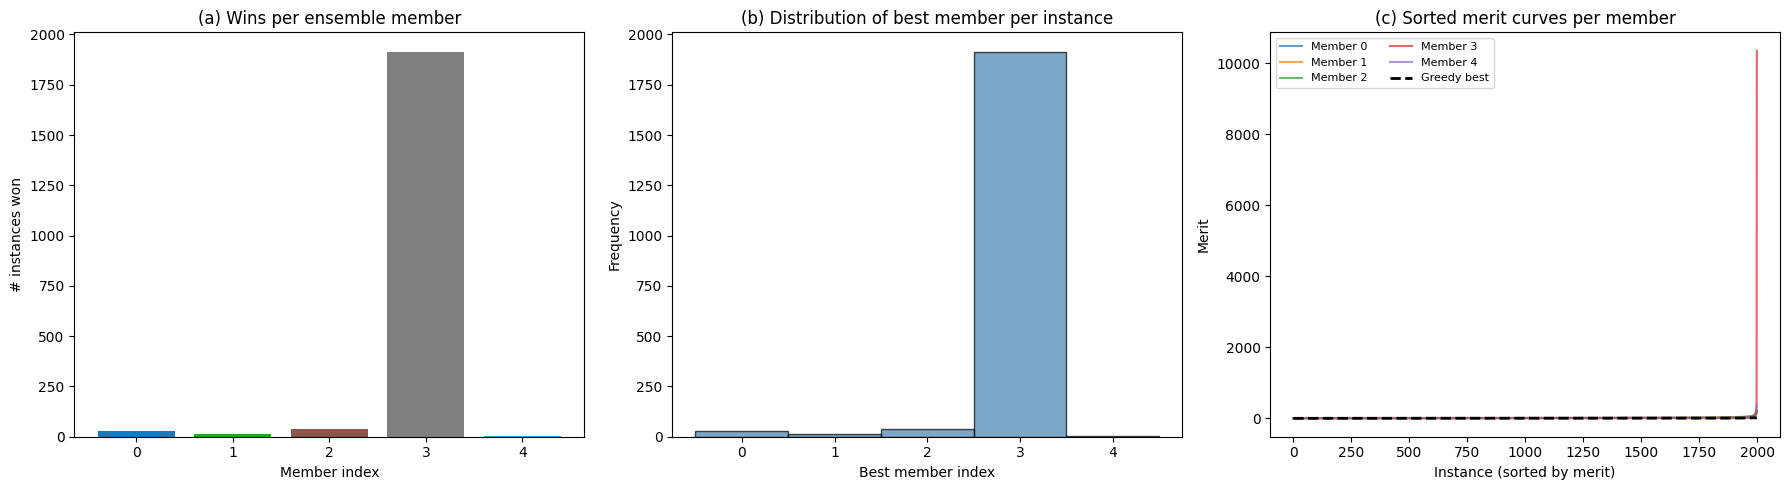

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Bar chart: wins per member ---
ax = axes[0]
member_ids = list(range(n_members))
counts = [win_counts.get(i, 0) for i in member_ids]
colors = plt.cm.tab10(np.linspace(0, 1, n_members))
ax.bar(member_ids, counts, color=colors)
ax.set_xlabel('Member index')
ax.set_ylabel('# instances won')
ax.set_title('(a) Wins per ensemble member')
ax.set_xticks(member_ids)

# --- (b) Histogram of best-member index across instances ---
ax = axes[1]
ax.hist(best_member_per_instance, bins=np.arange(-0.5, n_members + 0.5, 1),
        edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Best member index')
ax.set_ylabel('Frequency')
ax.set_title('(b) Distribution of best member per instance')
ax.set_xticks(member_ids)

# --- (c) Sorted merit per member to show overlap ---
ax = axes[2]
for m_idx in range(n_members):
    sorted_m = np.sort(merits[m_idx])
    ax.plot(sorted_m, label=f'Member {m_idx}', alpha=0.7)
# Also show the greedy-best merit
greedy_best = merits.min(axis=0)
ax.plot(np.sort(greedy_best), 'k--', linewidth=2, label='Greedy best')
ax.set_xlabel('Instance (sorted by merit)')
ax.set_ylabel('Merit')
ax.set_title('(c) Sorted merit curves per member')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [9]:
# --- Improvement from ensemble over single-best-overall model ---
mean_merits_per_member = merits.mean(axis=1)  # (M,)
overall_best_member = mean_merits_per_member.argmin()
print(f"Overall best single member (by mean merit): Member {overall_best_member}")
print(f"  Mean merit: {mean_merits_per_member[overall_best_member]:.4e}")

greedy_merit_per_instance = merits.min(axis=0)  # (N,)
greedy_mean = greedy_merit_per_instance.mean()
single_mean = mean_merits_per_member[overall_best_member]

improvement_abs = single_mean - greedy_mean
improvement_pct = 100 * improvement_abs / single_mean

print(f"\nGreedy-ensemble mean merit: {greedy_mean:.4e}")
print(f"Single-best mean merit:     {single_mean:.4e}")
print(f"Improvement:  {improvement_abs:.4e}  ({improvement_pct:.2f}%)")

if improvement_pct < 1:
    print("\n>> Ensemble barely helps over the single best model.")
else:
    print(f"\n>> Ensemble provides a {improvement_pct:.1f}% improvement — worth keeping.")

Overall best single member (by mean merit): Member 3
  Mean merit: 4.0811e+00

Greedy-ensemble mean merit: -2.1064e+00
Single-best mean merit:     4.0811e+00
Improvement:  6.1875e+00  (151.61%)

>> Ensemble provides a 151.6% improvement — worth keeping.


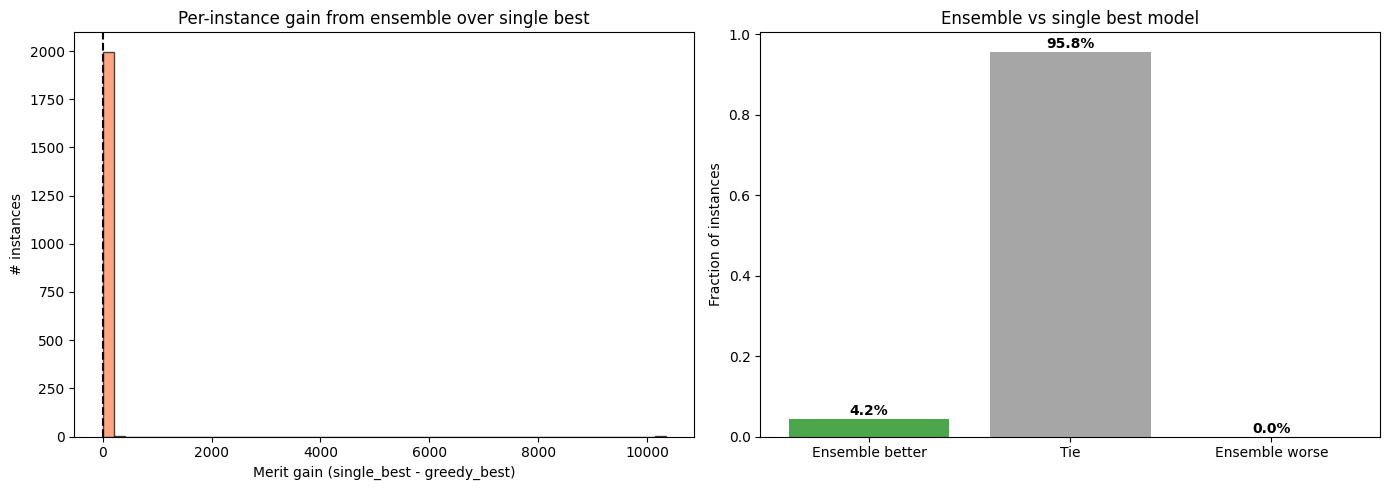

In [10]:
# --- Per-instance: how much does the greedy winner beat the single best model? ---
single_merits = merits[overall_best_member]  # (N,)
per_instance_gain = single_merits - greedy_merit_per_instance  # (N,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(per_instance_gain, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('Merit gain (single_best - greedy_best)')
ax.set_ylabel('# instances')
ax.set_title('Per-instance gain from ensemble over single best')

ax = axes[1]
frac_improved = (per_instance_gain > 0).mean()
frac_same = (per_instance_gain == 0).mean()
frac_worse = (per_instance_gain < 0).mean()
ax.bar(['Ensemble better', 'Tie', 'Ensemble worse'],
       [frac_improved, frac_same, frac_worse],
       color=['green', 'gray', 'red'], alpha=0.7)
ax.set_ylabel('Fraction of instances')
ax.set_title('Ensemble vs single best model')
for i, v in enumerate([frac_improved, frac_same, frac_worse]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# --- Summary table ---
print(f"{'Member':<10} {'Mean Merit':<14} {'Mean Obj':<14} {'Mean Eq Viol':<14} {'Mean Ineq Viol':<14} {'Wins':<8}")
print('-' * 74)
for m_idx in range(n_members):
    print(f"{m_idx:<10} {merits[m_idx].mean():<14.4e} {objs[m_idx].mean():<14.4e} "
          f"{eq_viols[m_idx].mean():<14.4e} {ineq_viols[m_idx].mean():<14.4e} {win_counts.get(m_idx, 0):<8}")
print('-' * 74)
print(f"{'Greedy':<10} {greedy_mean:<14.4e}")
print(f"{'Best-1':<10} {single_mean:<14.4e}  (Member {overall_best_member})")

Member     Mean Merit     Mean Obj       Mean Eq Viol   Mean Ineq Viol Wins    
--------------------------------------------------------------------------
0          7.2313e+00     1.7413e+00     5.4504e-05     3.9586e-07     26      
1          1.0313e+01     2.7954e+00     7.4637e-05     5.3761e-07     16      
2          6.1801e+00     2.6489e-01     5.8778e-05     3.7357e-07     37      
3          4.0811e+00     -2.8832e+00    6.2039e-05     7.6045e-06     1915    
4          7.9953e+00     6.4934e+00     1.4613e-05     4.0530e-07     6       
--------------------------------------------------------------------------
Greedy     -2.1064e+00   
Best-1     4.0811e+00      (Member 3)
